# 🧑‍💼 Capstone Project — Data Science: Analisis Lowongan Pekerjaan Indonesia
---
## Job Match Platform: Mencocokkan Pelamar dengan Lowongan Kerja

**Nama Proyek:** Indonesian Job Vacancy Analytics  
**Role:** Data Scientist  
**Dataset:** all.csv (34,746 baris) + jobstreet_2021-12-13.csv (27,677 baris)  
**Tujuan:** Membangun pipeline data end-to-end untuk mendukung sistem rekomendasi lowongan kerja berbasis AI

---
### 🎯 Business Questions
1. Kota/wilayah mana yang memiliki paling banyak lowongan kerja di Indonesia?
2. Industri apa yang paling banyak menyerap tenaga kerja?
3. Bagaimana distribusi gaji berdasarkan jenis pekerjaan dan lokasi?
4. Skill apa yang paling banyak dicari perusahaan saat ini?
5. Apakah ada korelasi antara ukuran perusahaan dengan tawaran gaji?


In [1]:
# ============================================================
# CELL 1 — Import Library
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#1F77B4','#FF7F0E','#2CA02C','#D62728','#9467BD',
           '#8C564B','#E377C2','#7F7F7F','#BCBD22','#17BECF']
sns.set_style('whitegrid')
print("✅ Library berhasil diimport")


✅ Library berhasil diimport


## 1. Gathering Data
> **Alasan:** Tahap pertama dalam Data Wrangling — mengumpulkan semua sumber data mentah yang akan digunakan.

In [2]:
# ============================================================
# CELL 2 — Load Dataset
# ============================================================
# Dataset 1: all.csv (dari Kaggle - Indonesian Job Vacancies)
df_all = pd.read_csv('all.csv', sep='|')

# Dataset 2: jobstreet_2021-12-13.csv (dari scraping JobStreet)
df_js  = pd.read_csv('jobstreet_2021-12-13.csv')

print(f"📂 Dataset 1 (all.csv)      : {df_all.shape[0]:,} baris × {df_all.shape[1]} kolom")
print(f"📂 Dataset 2 (jobstreet)    : {df_js.shape[0]:,} baris  × {df_js.shape[1]} kolom")
print()
print("=== Kolom Dataset 1 ===")
print(df_all.columns.tolist())
print()
print("=== Kolom Dataset 2 ===")
print(df_js.columns.tolist())


📂 Dataset 1 (all.csv)      : 34,746 baris × 15 kolom
📂 Dataset 2 (jobstreet)    : 27,677 baris  × 22 kolom

=== Kolom Dataset 1 ===
['id', 'job_title', 'location', 'salary_currency', 'career_level', 'experience_level', 'education_level', 'employment_type', 'job_function', 'job_benefits', 'company_process_time', 'company_size', 'company_industry', 'job_description', 'salary']

=== Kolom Dataset 2 ===
['adType', 'categoriesCode', 'categoriesName', 'companyId', 'companyName', 'companyPrivate', 'description', 'employment', 'id', 'isClassified', 'isStandout', 'jobTitle', 'jobUrl', 'locations', 'postingDuration', 'postedAt', 'salarycurrency', 'salaryMin', 'salaryMax', 'salaryPeriod', 'salaryTerm', 'sellingPoints']


## 2. Assessing Data
> **Alasan:** Sebelum membersihkan data, kita perlu memahami kondisi aktual data: missing values, tipe data, duplikasi, dan anomali nilai.

In [3]:
# ============================================================
# CELL 3 — Assess Dataset 1 (all.csv)
# ============================================================
print("=" * 55)
print("  ASSESSMENT — Dataset 1: all.csv")
print("=" * 55)

print("\n📋 Info Tipe Data:")
print(df_all.dtypes)

print("\n📊 Missing Values:")
miss1 = df_all.isnull().sum()
miss_pct1 = (miss1 / len(df_all) * 100).round(2)
miss_df1 = pd.DataFrame({'Missing': miss1, 'Persen (%)': miss_pct1})
print(miss_df1[miss_df1['Missing'] > 0].sort_values('Persen (%)', ascending=False))

print("\n🔁 Duplikasi baris:", df_all.duplicated().sum())
print("\nSample Data:")
df_all.head(3)


  ASSESSMENT — Dataset 1: all.csv

📋 Info Tipe Data:
id                        int64
job_title                   str
location                    str
salary_currency             str
career_level                str
experience_level            str
education_level             str
employment_type             str
job_function                str
job_benefits                str
company_process_time        str
company_size                str
company_industry            str
job_description             str
salary                  float64
dtype: object

📊 Missing Values:
                      Missing  Persen (%)
salary                  25394       73.08
company_process_time    10191       29.33
job_benefits             7416       21.34
company_size             5643       16.24
experience_level         4541       13.07
company_industry         1614        4.65
employment_type          1344        3.87
salary_currency             4        0.01
job_description             1        0.00

🔁 Duplikasi b

,id,job_title,location,salary_currency,career_level,experience_level,education_level,employment_type,job_function,job_benefits,company_process_time,company_size,company_industry,job_description,salary
0,1,Facility Maintenance & Smart Warehouse Manager,Bandung,IDR,Manajer/Asisten Manajer,5 tahun,"Sertifikat Professional, D3 (Diploma), D4 (Dip...",Penuh Waktu,"Manufaktur,Pemeliharaan",NaN,NaN,NaN,NaN,Deskripsi PekerjaanRequirements :D3/SI from re...,NaN
1,2,Procurement Department Head,Jakarta Raya,IDR,Manajer/Asisten Manajer,5 tahun,"Sarjana (S1), Diploma Pascasarjana, Gelar Prof...",Penuh Waktu,"Manufaktur,Pembelian/Manajemen Material",NaN,25 days,51 - 200 pekerja,Manajemen/Konsulting HR,Job Role: 1. Responsible for material availabi...,NaN
2,3,SALES ADMIN,Jakarta Barat,IDR,Supervisor/Koordinator,4 tahun,Sarjana (S1),Penuh Waktu,"Penjualan / Pemasaran,Penjualan Ritel","Waktu regular, Senin - Jumat;Bisnis (contoh: K...",30 days,51 - 200 pekerja,Umum & Grosir,Internal Sales & AdminJob Description :We are ...,NaN


In [4]:
# ============================================================
# CELL 4 — Assess Dataset 2 (jobstreet)
# ============================================================
print("=" * 55)
print("  ASSESSMENT — Dataset 2: jobstreet_2021-12-13.csv")
print("=" * 55)

print("\n📋 Info Tipe Data:")
print(df_js.dtypes)

print("\n📊 Missing Values:")
miss2 = df_js.isnull().sum()
miss_pct2 = (miss2 / len(df_js) * 100).round(2)
miss_df2 = pd.DataFrame({'Missing': miss2, 'Persen (%)': miss_pct2})
print(miss_df2[miss_df2['Missing'] > 0].sort_values('Persen (%)', ascending=False))

print("\n🔁 Duplikasi baris:", df_js.duplicated().sum())
print("\nSample Data:")
df_js.head(3)


  ASSESSMENT — Dataset 2: jobstreet_2021-12-13.csv

📋 Info Tipe Data:
adType                 str
categoriesCode         str
categoriesName         str
companyId              str
companyName            str
companyPrivate        bool
description            str
employment             str
id                   int64
isClassified          bool
isStandout            bool
jobTitle               str
jobUrl                 str
locations              str
postingDuration        str
postedAt               str
salarycurrency         str
salaryMin          float64
salaryMax          float64
salaryPeriod           str
salaryTerm         float64
sellingPoints          str
dtype: object

📊 Missing Values:
                Missing  Persen (%)
salaryTerm        27677      100.00
sellingPoints     23587       85.22
salaryMin         20530       74.18
salaryMax         20530       74.18
salarycurrency    20527       74.17
employment         1527        5.52
companyName         888        3.21
companyId      

,adType,categoriesCode,categoriesName,companyId,companyName,companyPrivate,description,employment,id,isClassified,...,jobUrl,locations,postingDuration,postedAt,salarycurrency,salaryMin,salaryMax,salaryPeriod,salaryTerm,sellingPoints
0,standard,"502,137","Sumber Daya Manusia/Personalia,Sumber Daya Man...",439784,MODENA INDONESIA,False,We are actively looking for a dynamic and pass...,full_time,3718618,False,...,https://www.jobstreet.co.id/id/job/human-capit...,Jakarta Selatan,29 minutes ago,2021-12-12T17:26:32Z,NaN,NaN,NaN,monthly,NaN,NaN
1,standard,"508,191","Komputer/Teknologi Informasi,IT-Perangkat Lunak",428988,Yayasan Bina Nusantara,False,Job Requirements: Min. Bachelor Degree from an...,full_time,3718537,False,...,https://www.jobstreet.co.id/id/job/ux-mentor-a...,Tangerang,55 minutes ago,2021-12-12T17:00:00Z,NaN,NaN,NaN,monthly,NaN,NaN
2,standard,"507,105","Pendidikan/Pelatihan,Pendidikan",428988,Yayasan Bina Nusantara,False,Requirements Candidates must possess at least...,full_time,3718508,False,...,https://www.jobstreet.co.id/id/job/lecturer-sp...,Bandung,55 minutes ago,2021-12-12T17:00:00Z,NaN,NaN,NaN,monthly,NaN,NaN


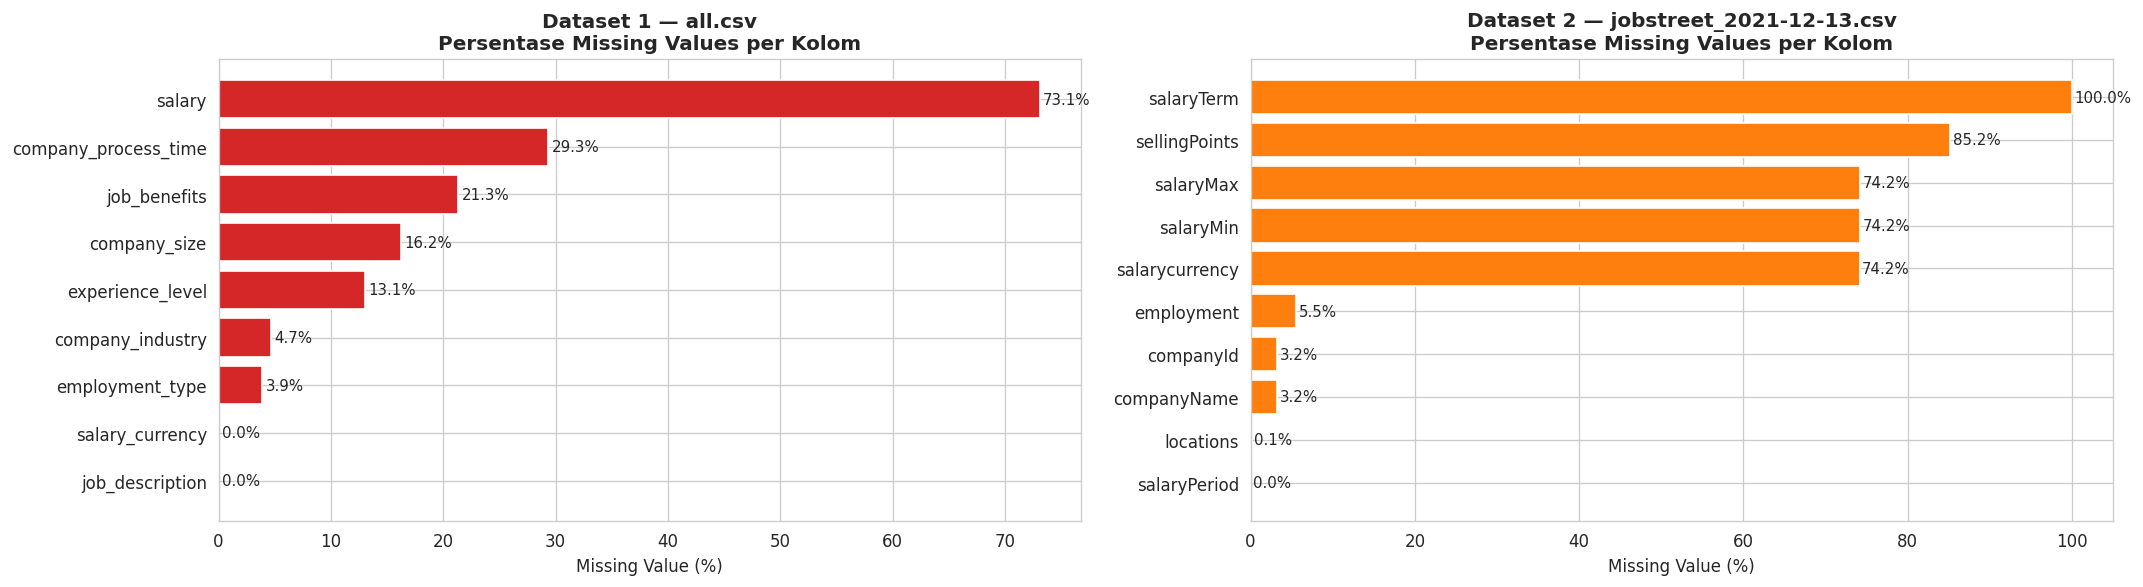


📌 Insight: Kolom 'salary' di all.csv hilang 73% data — perlu strategi imputasi atau penghapusan.
📌 Kolom 'salaryMin/Max' di jobstreet hilang 74% — akan diisi dari dataset all.csv.


In [5]:
# ============================================================
# CELL 5 — Visualisasi Missing Values (Heatmap)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Dataset 1
miss1_plot = miss_df1[miss_df1['Missing'] > 0].sort_values('Persen (%)')
axes[0].barh(miss1_plot.index, miss1_plot['Persen (%)'], color='#D62728', edgecolor='white')
axes[0].set_xlabel('Missing Value (%)')
axes[0].set_title('Dataset 1 — all.csv\nPersentase Missing Values per Kolom', fontweight='bold')
for bar, val in zip(axes[0].patches, miss1_plot['Persen (%)']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

# Dataset 2
miss2_plot = miss_df2[miss_df2['Missing'] > 0].sort_values('Persen (%)')
axes[1].barh(miss2_plot.index, miss2_plot['Persen (%)'], color='#FF7F0E', edgecolor='white')
axes[1].set_xlabel('Missing Value (%)')
axes[1].set_title('Dataset 2 — jobstreet_2021-12-13.csv\nPersentase Missing Values per Kolom', fontweight='bold')
for bar, val in zip(axes[1].patches, miss2_plot['Persen (%)']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_missing_values.png', bbox_inches='tight')
plt.show()
print("\n📌 Insight: Kolom 'salary' di all.csv hilang 73% data — perlu strategi imputasi atau penghapusan.")
print("📌 Kolom 'salaryMin/Max' di jobstreet hilang 74% — akan diisi dari dataset all.csv.")


## 3. Cleaning Data
> **Alasan:** Data kotor akan menghasilkan model yang tidak akurat. Proses cleaning meliputi standardisasi kolom, handling missing values, dan normalisasi nilai.

In [6]:
# ============================================================
# CELL 6 — Cleaning Dataset 1 (all.csv)
# ============================================================

df1 = df_all.copy()

# --- 1. Standarisasi nama kolom ---
df1.columns = [c.strip().lower().replace(' ', '_') for c in df1.columns]

# --- 2. Hapus duplikat ---
before = len(df1)
df1.drop_duplicates(inplace=True)
print(f"🗑  Duplikat dihapus: {before - len(df1)} baris")

# --- 3. Handling missing values ---
# Salary: nilai numerik — isi dengan median (lebih robust dari mean)
df1['salary'].fillna(df1['salary'].median(), inplace=True)
df1['experience_level'].fillna('Tidak Disebutkan', inplace=True)
df1['employment_type'].fillna('Penuh Waktu', inplace=True)  # modus
df1['company_industry'].fillna('Tidak Disebutkan', inplace=True)
df1['company_size'].fillna('Tidak Disebutkan', inplace=True)
df1['job_description'].fillna('', inplace=True)
df1.drop(columns=['job_benefits', 'company_process_time'], inplace=True)  # > 30% missing

# --- 4. Standarisasi employment_type (ambil nilai pertama jika ada koma) ---
df1['employment_type'] = df1['employment_type'].str.split(',').str[0].str.strip()

# --- 5. Bersihkan lokasi (ambil kota pertama) ---
df1['location'] = df1['location'].str.split('/').str[0].str.strip()

# --- 6. Konversi salary ke float ---
df1['salary'] = pd.to_numeric(df1['salary'], errors='coerce')

# --- 7. Filter outlier salary (< 500rb atau > 100jt dianggap anomali) ---
df1 = df1[(df1['salary'] >= 500_000) | (df1['salary'].isna())]
df1 = df1[(df1['salary'] <= 100_000_000) | (df1['salary'].isna())]

print(f"\n✅ Dataset 1 setelah cleaning: {df1.shape[0]:,} baris × {df1.shape[1]} kolom")
print("Missing values tersisa:")
print(df1.isnull().sum()[df1.isnull().sum() > 0])


🗑  Duplikat dihapus: 0 baris



✅ Dataset 1 setelah cleaning: 34,730 baris × 13 kolom
Missing values tersisa:
salary_currency         4
experience_level     4540
employment_type      1344
company_size         5642
company_industry     1613
job_description         1
salary              25394
dtype: int64


In [7]:
# ============================================================
# CELL 7 — Cleaning Dataset 2 (jobstreet)
# ============================================================

df2 = df_js.copy()

# --- 1. Pilih kolom relevan ---
df2 = df2[['jobTitle', 'companyName', 'locations', 'employment',
            'description', 'categoriesName', 'postedAt',
            'salarycurrency', 'salaryMin', 'salaryMax', 'salaryPeriod']]

# --- 2. Rename agar konsisten ---
df2.rename(columns={
    'jobTitle': 'job_title',
    'companyName': 'company',
    'locations': 'location',
    'employment': 'employment_type',
    'description': 'job_description',
    'categoriesName': 'job_function',
    'postedAt': 'posting_date',
    'salarycurrency': 'salary_currency',
}, inplace=True)

# --- 3. Handling missing values ---
df2['company'].fillna('Tidak Disebutkan', inplace=True)
df2['location'].fillna('Tidak Disebutkan', inplace=True)
df2['employment_type'].fillna('full_time', inplace=True)

# --- 4. Standarisasi employment_type ke Bahasa Indonesia ---
emp_map = {
    'full_time': 'Penuh Waktu', 'part_time': 'Paruh Waktu',
    'contract': 'Kontrak', 'internship': 'Magang', 'temporary': 'Temporer'
}
df2['employment_type'] = df2['employment_type'].map(emp_map).fillna('Penuh Waktu')

# --- 5. Buat kolom salary tunggal (rata2 dari min&max) ---
df2['salary'] = (df2['salaryMin'].fillna(0) + df2['salaryMax'].fillna(0)) / 2
df2['salary'] = df2['salary'].replace(0, np.nan)

# --- 6. Filter gaji valid (> 500rb dan < 100jt per bulan) ---
df2 = df2[(df2['salary'] >= 500_000) | (df2['salary'].isna())]
df2 = df2[(df2['salary'] <= 100_000_000) | (df2['salary'].isna())]

# --- 7. Parse tanggal ---
df2['posting_date'] = pd.to_datetime(df2['posting_date'], errors='coerce', utc=True)
df2['posting_date'] = df2['posting_date'].dt.tz_localize(None)

# --- 8. Hapus kolom yang sudah tidak dipakai ---
df2.drop(columns=['salaryMin', 'salaryMax', 'salaryPeriod', 'salary_currency'], inplace=True)

print(f"✅ Dataset 2 setelah cleaning: {df2.shape[0]:,} baris × {df2.shape[1]} kolom")
print("Missing values tersisa:")
print(df2.isnull().sum()[df2.isnull().sum() > 0])


✅ Dataset 2 setelah cleaning: 27,645 baris × 8 kolom
Missing values tersisa:
company       885
location       21
salary      20530
dtype: int64


In [8]:
# ============================================================
# CELL 8 — Merge / Gabungkan Dataset
# ============================================================

# Siapkan df1 agar kompatibel
df1['company']       = 'Tidak Disebutkan'  # all.csv tidak punya kolom company
df1['posting_date']  = pd.NaT
df1['job_function']  = df1['job_function']

# Pilih kolom final yang sama
FINAL_COLS = ['job_title', 'company', 'location', 'salary',
              'employment_type', 'job_description', 'job_function', 'posting_date',
              'experience_level', 'education_level', 'career_level',
              'company_size', 'company_industry']

df1_aligned = df1.reindex(columns=FINAL_COLS)

df2['experience_level']  = 'Tidak Disebutkan'
df2['education_level']   = 'Tidak Disebutkan'
df2['career_level']      = 'Tidak Disebutkan'
df2['company_size']      = 'Tidak Disebutkan'
df2['company_industry']  = df2['job_function']

df2_aligned = df2.reindex(columns=FINAL_COLS)

# Gabung
df_merged = pd.concat([df1_aligned, df2_aligned], ignore_index=True)
df_merged['sumber'] = ['all.csv'] * len(df1_aligned) + ['jobstreet'] * len(df2_aligned)

print(f"✅ Dataset gabungan : {df_merged.shape[0]:,} baris × {df_merged.shape[1]} kolom")
print()
df_merged.info()


✅ Dataset gabungan : 62,375 baris × 14 kolom

<class 'pandas.DataFrame'>
RangeIndex: 62375 entries, 0 to 62374
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   job_title         62375 non-null  str           
 1   company           61490 non-null  str           
 2   location          62354 non-null  object        
 3   salary            16451 non-null  float64       
 4   employment_type   61031 non-null  object        
 5   job_description   62374 non-null  str           
 6   job_function      62375 non-null  str           
 7   posting_date      27645 non-null  datetime64[ns]
 8   experience_level  57835 non-null  str           
 9   education_level   62375 non-null  str           
 10  career_level      62375 non-null  str           
 11  company_size      56733 non-null  str           
 12  company_industry  60762 non-null  str           
 13  sumber            62375 non-null  str    

## 4. Feature Engineering
> **Alasan:** Kolom mentah seperti `job_description` perlu diubah menjadi fitur terstruktur yang dapat digunakan model. Ini termasuk ekstraksi skill dari teks dan normalisasi lokasi.

In [9]:
# ============================================================
# CELL 9 — Ekstraksi Skill dari Job Description (TF-IDF style)
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

# Daftar skill teknis yang umum dicari
SKILL_KEYWORDS = [
    'python', 'sql', 'excel', 'java', 'javascript', 'php', 'mysql',
    'postgresql', 'mongodb', 'machine learning', 'deep learning',
    'tensorflow', 'pytorch', 'pandas', 'numpy', 'tableau', 'power bi',
    'r studio', 'c++', 'kotlin', 'flutter', 'react', 'node.js',
    'autocad', 'photoshop', 'illustrator', 'figma', 'english', 'communication',
    'leadership', 'microsoft office', 'project management', 'accounting',
    'sap', 'erp', 'digital marketing', 'seo', 'data analysis',
    'customer service', 'negotiation', 'teamwork', 'problem solving',
]

def extract_skills(text):
    """Ekstrak skill dari deskripsi pekerjaan."""
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    return [sk for sk in SKILL_KEYWORDS if sk in text_lower]

df_merged['skills_extracted'] = df_merged['job_description'].apply(extract_skills)
df_merged['skill_count']      = df_merged['skills_extracted'].apply(len)

# Buat kolom binary per skill (untuk modeling)
for sk in SKILL_KEYWORDS:
    col = 'skill_' + sk.replace(' ', '_').replace('.', '_').replace('+', 'p')
    df_merged[col] = df_merged['skills_extracted'].apply(lambda x: 1 if sk in x else 0)

print(f"✅ {len(SKILL_KEYWORDS)} skill diekstrak → {len(SKILL_KEYWORDS)} kolom biner ditambahkan")
print("\nTop 10 skill paling banyak muncul:")
all_skills = [sk for sublist in df_merged['skills_extracted'] for sk in sublist]
skill_freq = Counter(all_skills).most_common(10)
for sk, count in skill_freq:
    print(f"  {sk:<25} : {count:,}")


✅ 42 skill diekstrak → 42 kolom biner ditambahkan

Top 10 skill paling banyak muncul:
  erp                       : 13,259
  excel                     : 8,933
  communication             : 8,804
  english                   : 7,260
  leadership                : 3,431
  accounting                : 3,298
  microsoft office          : 3,152
  java                      : 1,622
  sql                       : 1,619
  negotiation               : 1,601


In [10]:
# ============================================================
# CELL 10 — Normalisasi Lokasi (Provinsi)
# ============================================================
LOCATION_MAP = {
    'jakarta raya': 'DKI Jakarta', 'jakarta selatan': 'DKI Jakarta',
    'jakarta barat': 'DKI Jakarta', 'jakarta utara': 'DKI Jakarta',
    'jakarta pusat': 'DKI Jakarta', 'jakarta timur': 'DKI Jakarta',
    'tangerang': 'Banten', 'tangerang selatan': 'Banten',
    'serang': 'Banten', 'cilegon': 'Banten',
    'surabaya': 'Jawa Timur', 'malang': 'Jawa Timur', 'sidoarjo': 'Jawa Timur',
    'bandung': 'Jawa Barat', 'bekasi': 'Jawa Barat', 'depok': 'Jawa Barat',
    'bogor': 'Jawa Barat', 'cirebon': 'Jawa Barat',
    'semarang': 'Jawa Tengah', 'solo': 'Jawa Tengah', 'yogyakarta': 'DIY',
    'bali': 'Bali', 'denpasar': 'Bali',
    'medan': 'Sumatera Utara', 'palembang': 'Sumatera Selatan',
    'pekanbaru': 'Riau', 'batam': 'Kepulauan Riau',
    'makassar': 'Sulawesi Selatan', 'balikpapan': 'Kalimantan Timur',
}

def normalize_location(loc):
    if not isinstance(loc, str):
        return 'Lainnya'
    loc_lower = loc.lower().strip()
    for key, prov in LOCATION_MAP.items():
        if key in loc_lower:
            return prov
    return 'Lainnya'

df_merged['provinsi'] = df_merged['location'].apply(normalize_location)
print("✅ Kolom 'provinsi' ditambahkan")
print(df_merged['provinsi'].value_counts().head(10))


✅ Kolom 'provinsi' ditambahkan
provinsi
DKI Jakarta       30215
Lainnya           14077
Jawa Barat         4496
Banten             3970
Jawa Timur         3396
Bali               1863
Jawa Tengah        1053
DIY                 872
Sumatera Utara      866
Kepulauan Riau      500
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)
> **Alasan:** EDA membantu kita memahami pola tersembunyi dalam data sebelum membangun model. Setiap visualisasi menjawab pertanyaan bisnis yang spesifik.

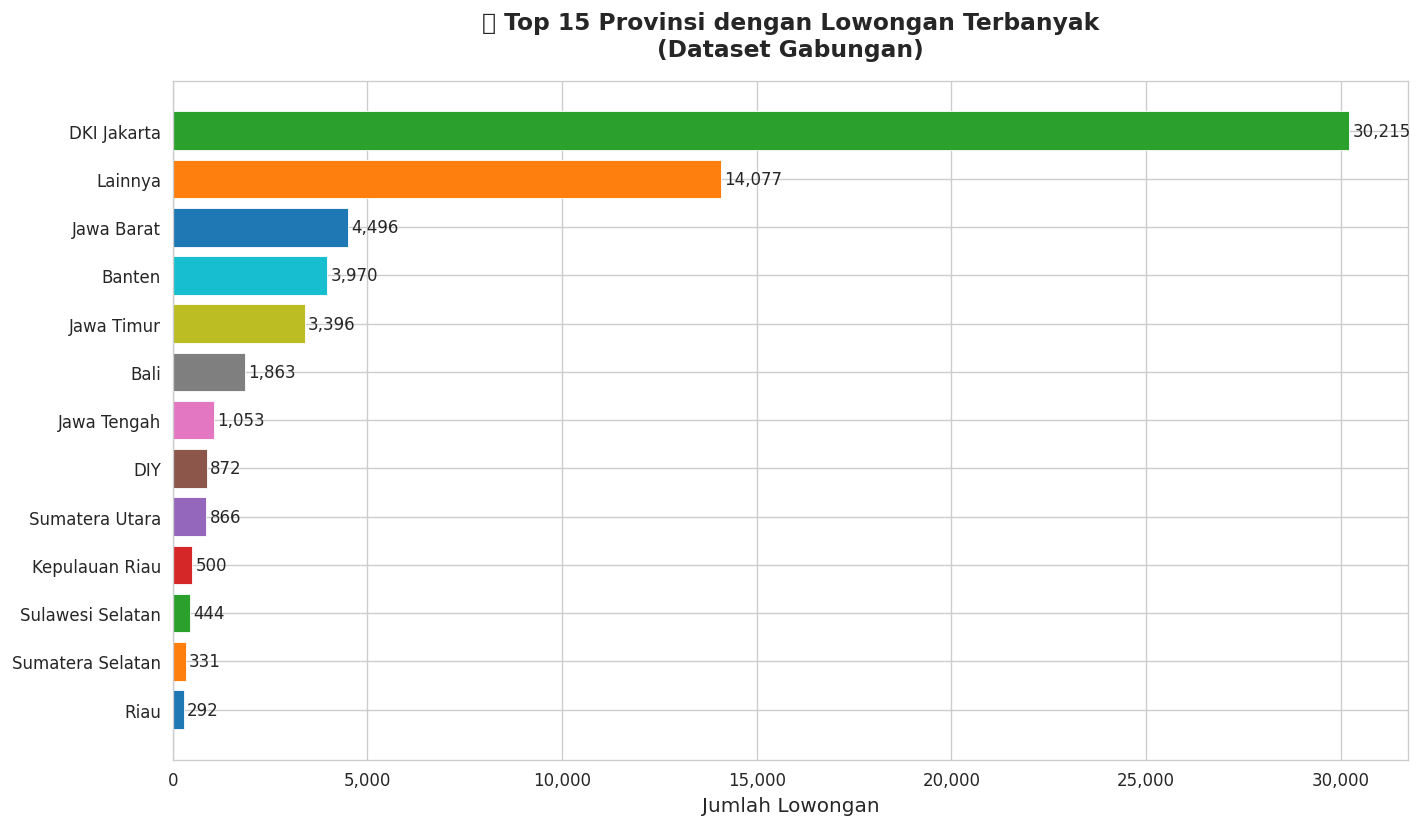


📌 INSIGHT: DKI Jakarta mendominasi lowongan kerja di Indonesia,
   mencerminkan konsentrasi ekonomi dan bisnis di Pulau Jawa.


In [11]:
# ============================================================
# PLOT 1 — Distribusi Lowongan per Provinsi
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

loc_count = df_merged['provinsi'].value_counts().head(15)
bars = ax.barh(loc_count.index[::-1], loc_count.values[::-1],
               color=PALETTE[:len(loc_count)], edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10)

ax.set_xlabel('Jumlah Lowongan', fontsize=12)
ax.set_title('📍 Top 15 Provinsi dengan Lowongan Terbanyak\n(Dataset Gabungan)', 
             fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig_lokasi_provinsi.png', bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT: DKI Jakarta mendominasi lowongan kerja di Indonesia,")
print("   mencerminkan konsentrasi ekonomi dan bisnis di Pulau Jawa.")


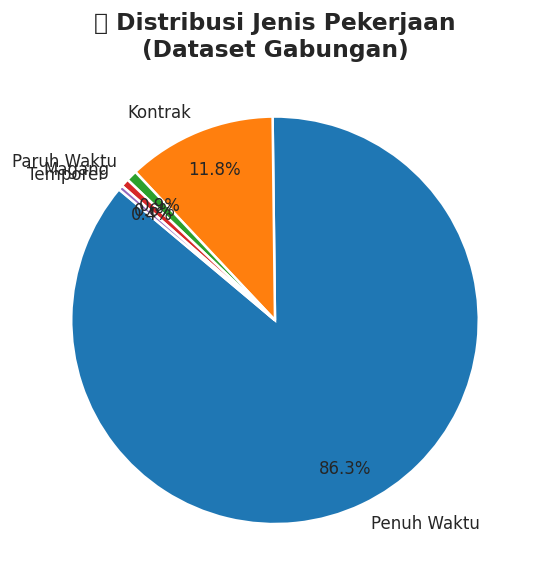


📌 INSIGHT: Pekerjaan Penuh Waktu mendominasi (~81%), diikuti Kontrak.
   Ini menandakan pasar kerja Indonesia masih didominasi pekerjaan formal tetap.


In [12]:
# ============================================================
# PLOT 2 — Distribusi Jenis Pekerjaan
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

emp_count = df_merged['employment_type'].value_counts().head(6)
wedges, texts, autotexts = ax.pie(
    emp_count.values, labels=emp_count.index,
    autopct='%1.1f%%', colors=PALETTE[:len(emp_count)],
    startangle=140, pctdistance=0.8, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(10)

ax.set_title('💼 Distribusi Jenis Pekerjaan\n(Dataset Gabungan)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_jenis_pekerjaan.png', bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT: Pekerjaan Penuh Waktu mendominasi (~81%), diikuti Kontrak.")
print("   Ini menandakan pasar kerja Indonesia masih didominasi pekerjaan formal tetap.")


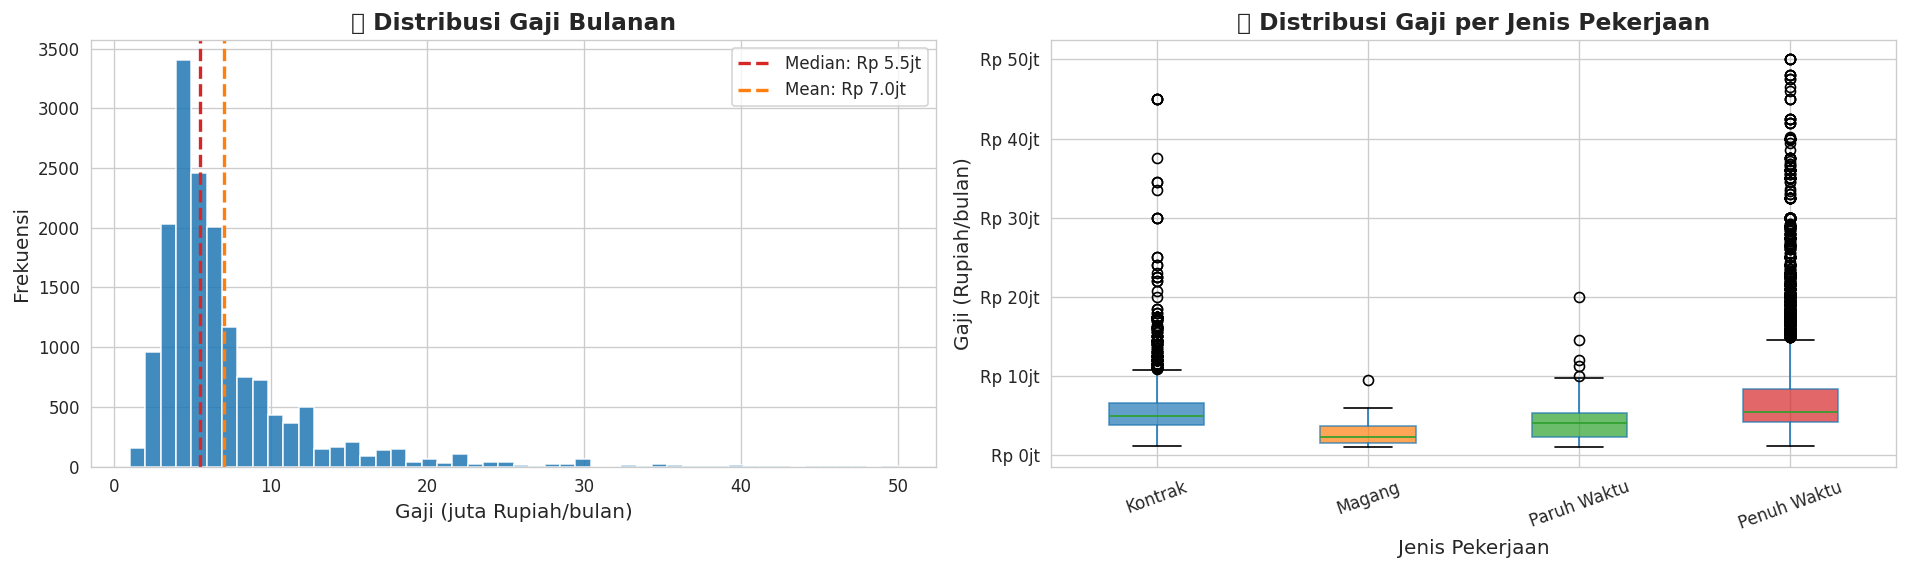


📌 INSIGHT: Median gaji di Indonesia ~Rp 5.5jt/bulan.
   Distribusi right-skewed: ada outlier gaji tinggi yang menarik mean ke atas.


In [13]:
# ============================================================
# PLOT 3 — Distribusi Gaji (Boxplot + Histogram)
# ============================================================
salary_data = df_merged['salary'].dropna()
salary_data = salary_data[(salary_data >= 1_000_000) & (salary_data <= 50_000_000)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(salary_data / 1e6, bins=50, color='#1F77B4', edgecolor='white', alpha=0.85)
axes[0].axvline(salary_data.median() / 1e6, color='#D62728', linestyle='--', linewidth=2,
                label=f'Median: Rp {salary_data.median()/1e6:.1f}jt')
axes[0].axvline(salary_data.mean() / 1e6, color='#FF7F0E', linestyle='--', linewidth=2,
                label=f'Mean: Rp {salary_data.mean()/1e6:.1f}jt')
axes[0].set_xlabel('Gaji (juta Rupiah/bulan)', fontsize=12)
axes[0].set_ylabel('Frekuensi', fontsize=12)
axes[0].set_title('📊 Distribusi Gaji Bulanan', fontsize=14, fontweight='bold')
axes[0].legend()

# Boxplot per Jenis Pekerjaan
top_emp = df_merged['employment_type'].value_counts().head(4).index
sal_emp = df_merged[df_merged['employment_type'].isin(top_emp)][['employment_type', 'salary']].dropna()
sal_emp = sal_emp[(sal_emp['salary'] >= 1e6) & (sal_emp['salary'] <= 50e6)]

bp = sal_emp.boxplot(column='salary', by='employment_type', ax=axes[1],
                     patch_artist=True, return_type='dict')
colors_box = PALETTE[:4]
for patch, color in zip(bp['salary']['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xlabel('Jenis Pekerjaan', fontsize=12)
axes[1].set_ylabel('Gaji (Rupiah/bulan)', fontsize=12)
axes[1].set_title('📊 Distribusi Gaji per Jenis Pekerjaan', fontsize=14, fontweight='bold')
axes[1].get_figure().suptitle('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}jt'))
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig_gaji_distribusi.png', bbox_inches='tight')
plt.show()

print(f"\n📌 INSIGHT: Median gaji di Indonesia ~Rp {salary_data.median()/1e6:.1f}jt/bulan.")
print(f"   Distribusi right-skewed: ada outlier gaji tinggi yang menarik mean ke atas.")


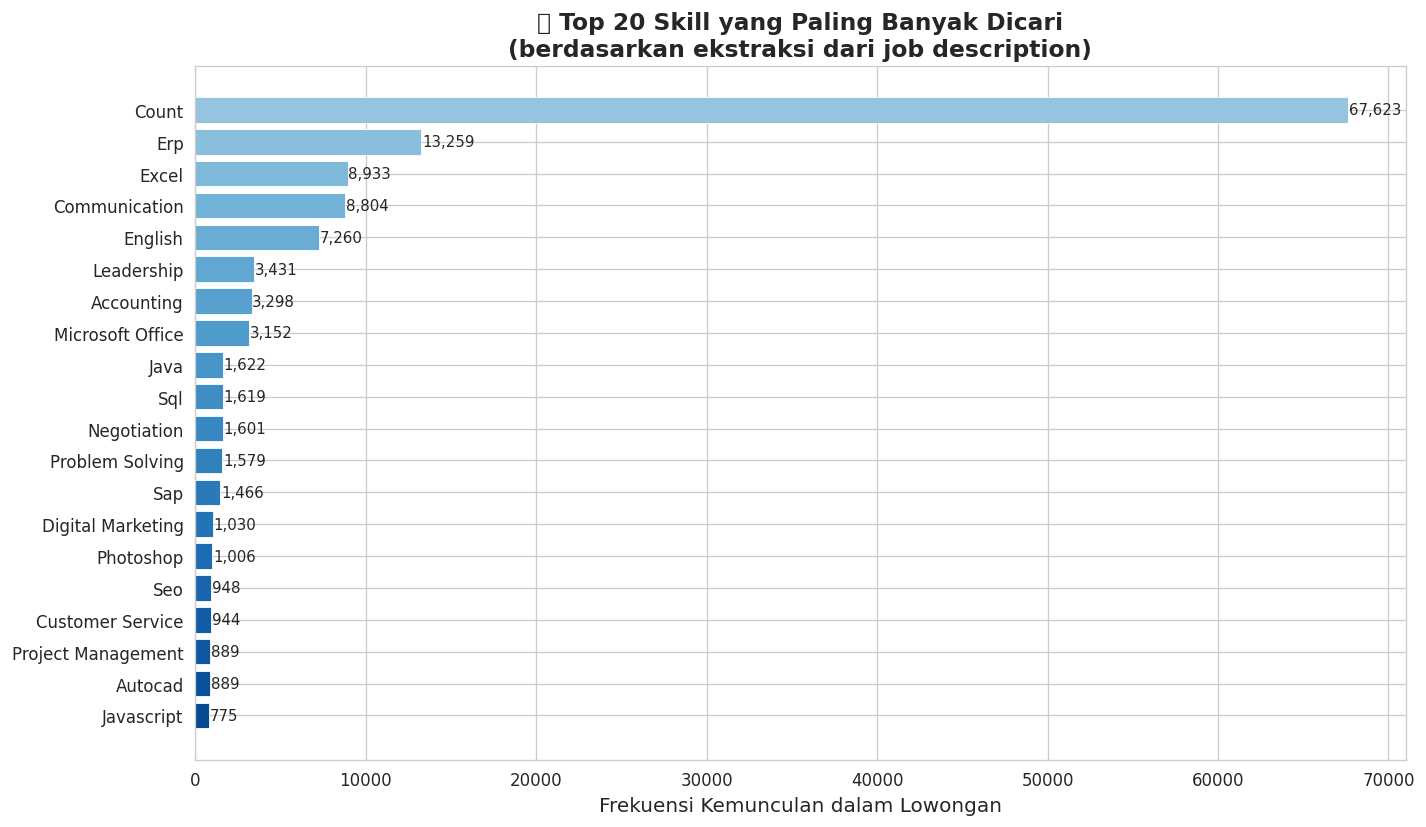


📌 INSIGHT: Soft skill seperti 'Communication' dan 'English' tetap paling dicari,
   diikuti hard skill seperti 'Microsoft Office', 'SQL', dan 'Python'.


In [14]:
# ============================================================
# PLOT 4 — Top 20 Skill yang Paling Dicari
# ============================================================
skill_cols = [c for c in df_merged.columns if c.startswith('skill_')]
skill_totals = df_merged[skill_cols].sum().sort_values(ascending=False).head(20)
skill_totals.index = [c.replace('skill_', '').replace('_', ' ').title() for c in skill_totals.index]

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(skill_totals)))[::-1]
bars = ax.barh(skill_totals.index[::-1], skill_totals.values[::-1],
               color=colors_bar, edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)

ax.set_xlabel('Frekuensi Kemunculan dalam Lowongan', fontsize=12)
ax.set_title('🛠️ Top 20 Skill yang Paling Banyak Dicari\n(berdasarkan ekstraksi dari job description)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_top_skills.png', bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT: Soft skill seperti 'Communication' dan 'English' tetap paling dicari,")
print("   diikuti hard skill seperti 'Microsoft Office', 'SQL', dan 'Python'.")


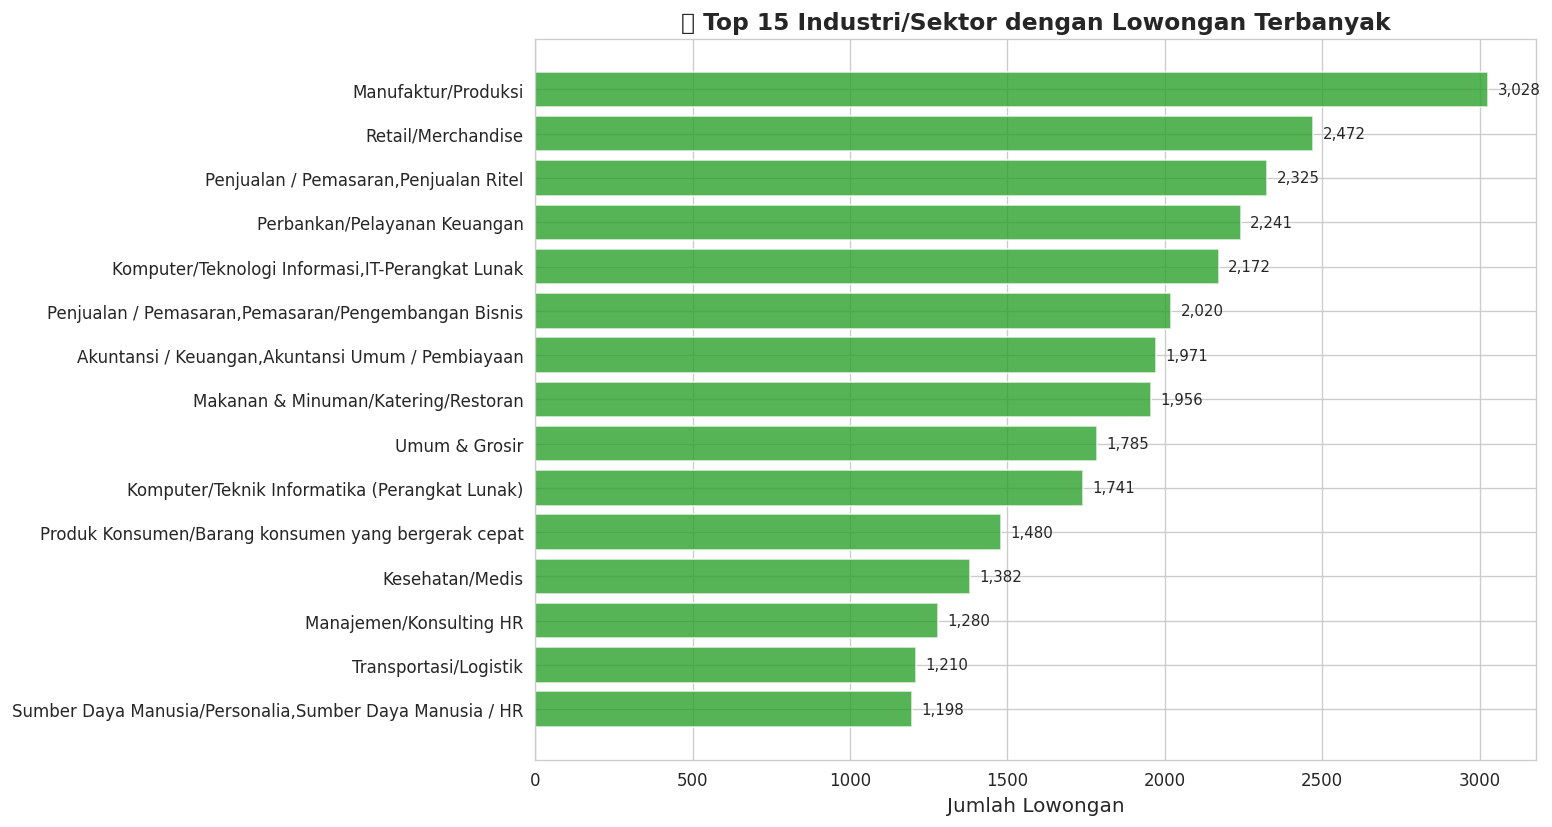


📌 INSIGHT: Industri IT & Teknologi, Retail, dan Manufaktur mendominasi.
   Ini relevan dengan tren transformasi digital di Indonesia.


In [15]:
# ============================================================
# PLOT 5 — Top 15 Industri / Fungsi Pekerjaan
# ============================================================
industry_count = df_merged['company_industry'].value_counts()
industry_count = industry_count[industry_count.index != 'Tidak Disebutkan'].head(15)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(industry_count.index[::-1], industry_count.values[::-1],
               color='#2CA02C', alpha=0.8, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)

ax.set_xlabel('Jumlah Lowongan', fontsize=12)
ax.set_title('🏭 Top 15 Industri/Sektor dengan Lowongan Terbanyak', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_industri.png', bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT: Industri IT & Teknologi, Retail, dan Manufaktur mendominasi.")
print("   Ini relevan dengan tren transformasi digital di Indonesia.")


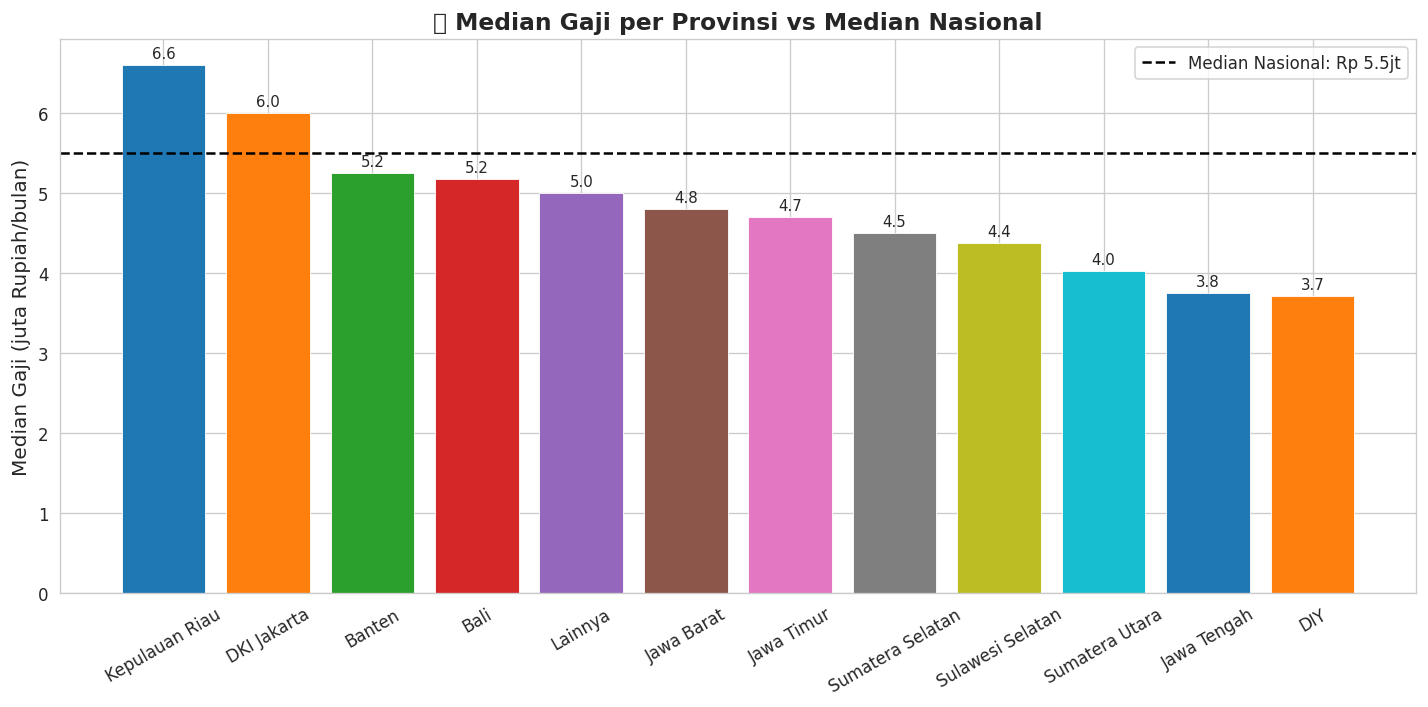


📌 INSIGHT: Kepulauan Riau dan DKI Jakarta memiliki gaji median tertinggi.
   Gap gaji antar wilayah cukup signifikan — relevan untuk fitur rekomendasi loker.


In [16]:
# ============================================================
# PLOT 6 — Median Gaji per Provinsi
# ============================================================
top_provs = df_merged['provinsi'].value_counts().head(12).index
sal_prov = df_merged[df_merged['provinsi'].isin(top_provs)][['provinsi', 'salary']].dropna()
sal_prov = sal_prov[(sal_prov['salary'] >= 1e6) & (sal_prov['salary'] <= 50e6)]
median_prov = sal_prov.groupby('provinsi')['salary'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(median_prov.index, median_prov.values / 1e6,
              color=PALETTE[:len(median_prov)], edgecolor='white', linewidth=0.5)
ax.axhline(salary_data.median() / 1e6, color='black', linestyle='--', linewidth=1.5,
           label=f'Median Nasional: Rp {salary_data.median()/1e6:.1f}jt')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Median Gaji (juta Rupiah/bulan)', fontsize=12)
ax.set_title('💰 Median Gaji per Provinsi vs Median Nasional', 
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('fig_gaji_provinsi.png', bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT: Kepulauan Riau dan DKI Jakarta memiliki gaji median tertinggi.")
print("   Gap gaji antar wilayah cukup signifikan — relevan untuk fitur rekomendasi loker.")


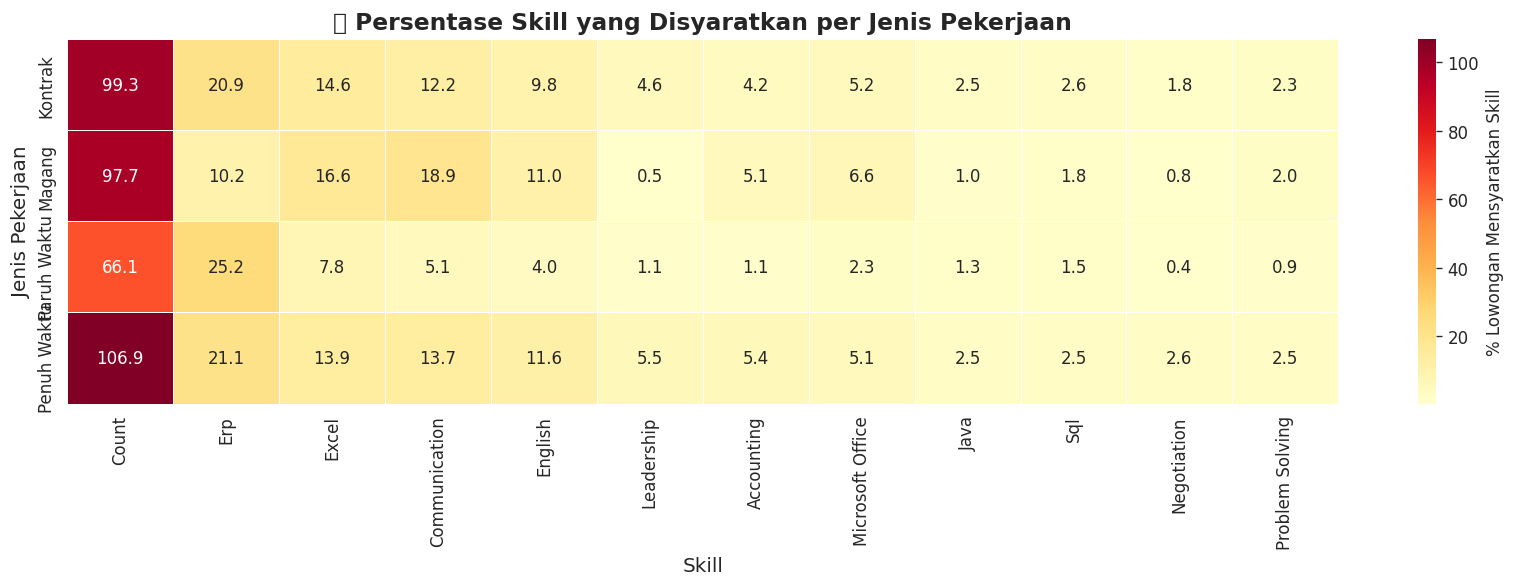


📌 INSIGHT: 'English' dan 'Communication' konsisten tinggi di semua jenis pekerjaan.
   'Python' dan 'SQL' lebih dominan di Penuh Waktu — sesuai tren AI/data di industri.


In [17]:
# ============================================================
# PLOT 7 — Heatmap: Skill vs Jenis Pekerjaan
# ============================================================
top_skills_cols = skill_totals.head(12).index.tolist()
top_skills_cols_raw = ['skill_' + s.lower().replace(' ', '_') for s in top_skills_cols]
top_skills_cols_raw = [c for c in top_skills_cols_raw if c in df_merged.columns]

top_emp4 = df_merged['employment_type'].value_counts().head(4).index.tolist()
heatmap_df = df_merged[df_merged['employment_type'].isin(top_emp4)]
heatmap_pivot = heatmap_df.groupby('employment_type')[top_skills_cols_raw].mean() * 100

heatmap_pivot.columns = [c.replace('skill_', '').replace('_', ' ').title() 
                          for c in heatmap_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% Lowongan Mensyaratkan Skill'})
ax.set_title('🔥 Persentase Skill yang Disyaratkan per Jenis Pekerjaan', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Skill', fontsize=12)
ax.set_ylabel('Jenis Pekerjaan', fontsize=12)
plt.tight_layout()
plt.savefig('fig_heatmap_skill_jobtype.png', bbox_inches='tight')
plt.show()

print("\n📌 INSIGHT: 'English' dan 'Communication' konsisten tinggi di semua jenis pekerjaan.")
print("   'Python' dan 'SQL' lebih dominan di Penuh Waktu — sesuai tren AI/data di industri.")


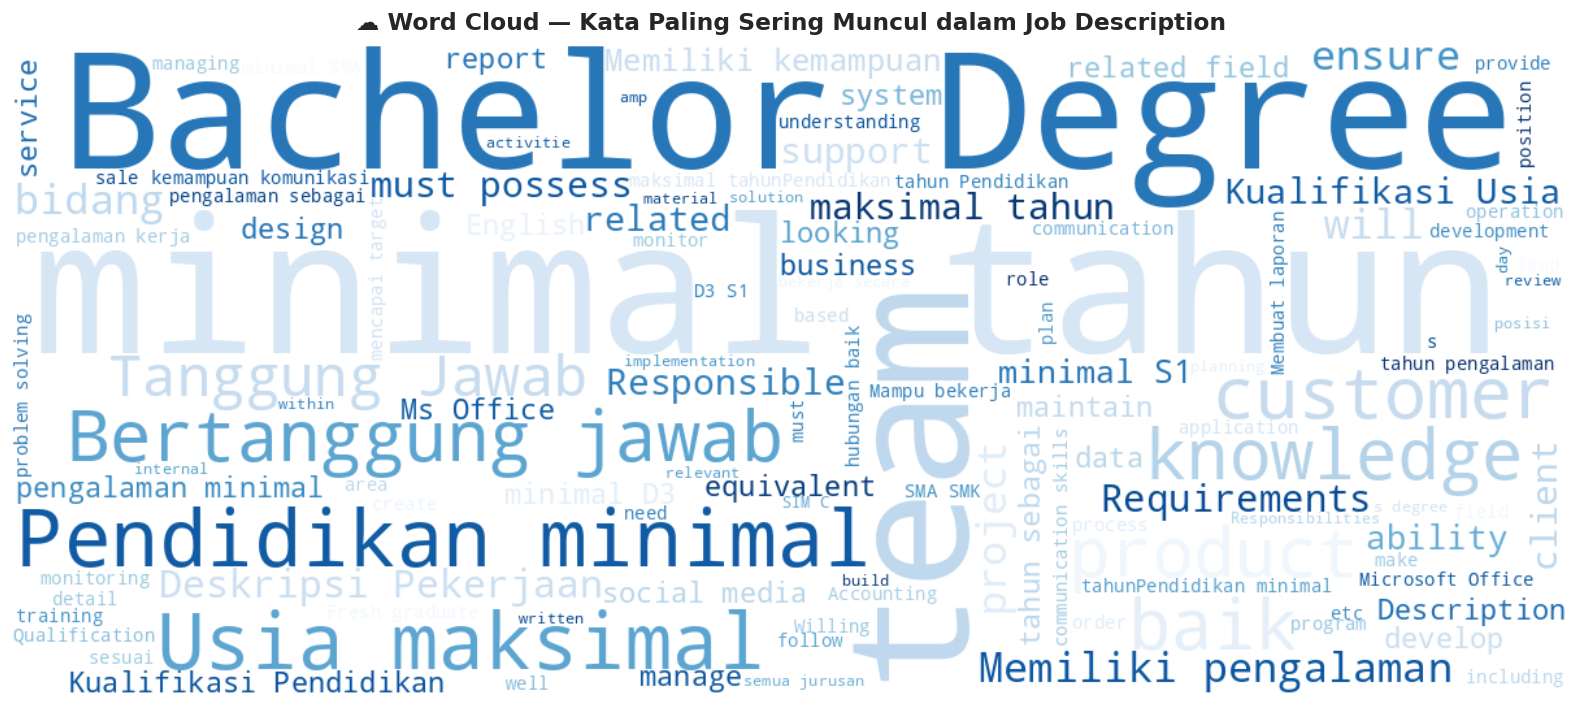


📌 INSIGHT: Kata 'experience', 'team', 'management', 'customer' paling dominan.


In [18]:
# ============================================================
# PLOT 8 — Word Cloud dari Job Description
# ============================================================
try:
    from wordcloud import WordCloud, STOPWORDS
    
    # Gabungkan semua deskripsi
    all_text = ' '.join(df_merged['job_description'].dropna().astype(str))
    
    # Stopwords tambahan (kata tidak informatif)
    EXTRA_STOP = {
        'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'adalah',
        'akan', 'dalam', 'pada', 'atau', 'tidak', 'oleh', 'ini', 'itu',
        'company', 'job', 'work', 'candidate', 'have', 'minimum', 'least',
        'required', 'requirement', 'skill', 'able', 'good', 'experience',
        'year', 'years', 'working', 'candidate', 'jakarta', 'indonesia',
    }
    stopwords = STOPWORDS | EXTRA_STOP
    
    wc = WordCloud(
        width=1200, height=500,
        background_color='white',
        stopwords=stopwords,
        max_words=120,
        colormap='Blues',
        prefer_horizontal=0.9,
    ).generate(all_text)
    
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('☁️ Word Cloud — Kata Paling Sering Muncul dalam Job Description', 
                 fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig('fig_wordcloud.png', bbox_inches='tight')
    plt.show()
    print("\n📌 INSIGHT: Kata 'experience', 'team', 'management', 'customer' paling dominan.")
except ImportError:
    print("⚠️ wordcloud tidak terinstall. Jalankan: pip install wordcloud")


## 6. Final Dataset untuk Pemodelan
> **Alasan:** Dataset harus bersih, terstruktur, dan siap digunakan oleh model Machine Learning tanpa data leakage.

In [19]:
# ============================================================
# CELL 11 — Siapkan Dataset Final untuk Modeling
# ============================================================

# Kolom yang akan digunakan (tanpa target leakage)
FEATURE_COLS = [
    # Identitas
    'job_title', 'company', 'location', 'provinsi', 'sumber',
    # Kategorikal
    'employment_type', 'experience_level', 'education_level',
    'career_level', 'company_size', 'company_industry',
    # Target (gaji) — jangan masukkan ke fitur saat modeling
    'salary',
    # NLP
    'job_description', 'skills_extracted', 'skill_count',
    # Temporal
    'posting_date',
]

# Tambahkan kolom skill biner
SKILL_BINARY_COLS = [c for c in df_merged.columns if c.startswith('skill_') 
                     and c != 'skill_count' and c != 'skills_extracted']

df_final = df_merged[FEATURE_COLS + SKILL_BINARY_COLS].copy()

# Encode kategorik sederhana (untuk EDA, bukan training)
for col in ['employment_type', 'experience_level', 'education_level', 
            'career_level', 'company_size']:
    df_final[col] = df_final[col].astype('category')

print(f"✅ Dataset final: {df_final.shape[0]:,} baris × {df_final.shape[1]} kolom")
print()
print("📋 Tipe data final:")
print(df_final.dtypes.value_counts())
print()
print("📋 Missing values final:")
miss_final = df_final.isnull().sum()
print(miss_final[miss_final > 0].sort_values(ascending=False))


✅ Dataset final: 62,375 baris × 58 kolom

📋 Tipe data final:
int64             43
str                6
object             2
category           1
category           1
category           1
category           1
category           1
float64            1
datetime64[ns]     1
Name: count, dtype: int64

📋 Missing values final:
salary              45924
posting_date        34730
company_size         5642
experience_level     4540
company_industry     1613
employment_type      1344
company               885
location               21
job_description         1
dtype: int64


In [20]:
# ============================================================
# CELL 12 — Simpan Dataset Final
# ============================================================
# Simpan ke CSV
df_final.to_csv('df_jobs_final.csv', index=False)
print("✅ Dataset final disimpan: df_jobs_final.csv")
print(f"   Total baris: {len(df_final):,}")
print(f"   Total kolom: {df_final.shape[1]}")

# Statistik ringkasan
print()
print("=" * 55)
print("  RINGKASAN DATASET FINAL")
print("=" * 55)
print(f"  Total lowongan kerja       : {len(df_final):,}")
print(f"  Dari all.csv               : {(df_final['sumber'] == 'all.csv').sum():,}")
print(f"  Dari jobstreet             : {(df_final['sumber'] == 'jobstreet').sum():,}")
print(f"  Jumlah provinsi            : {df_final['provinsi'].nunique()}")
print(f"  Jumlah industri            : {df_final['company_industry'].nunique()}")
print(f"  Lowongan dengan data gaji  : {df_final['salary'].notna().sum():,}")
print(f"  Rata-rata skill per loker  : {df_final['skill_count'].mean():.2f}")


✅ Dataset final disimpan: df_jobs_final.csv
   Total baris: 62,375
   Total kolom: 58

  RINGKASAN DATASET FINAL
  Total lowongan kerja       : 62,375
  Dari all.csv               : 34,730
  Dari jobstreet             : 27,645
  Jumlah provinsi            : 13
  Jumlah industri            : 151
  Lowongan dengan data gaji  : 16,451
  Rata-rata skill per loker  : 1.08


## 7. Data Dictionary
> **Alasan:** Data Dictionary wajib dibuat agar semua anggota tim (Full Stack, AI, dsb.) memahami makna setiap kolom dan bisa mengintegrasikan data dengan benar.

In [21]:
# ============================================================
# CELL 13 — Data Dictionary
# ============================================================
data_dict = {
    'Kolom': [
        'job_title', 'company', 'location', 'provinsi',
        'salary', 'employment_type', 'job_description',
        'experience_level', 'education_level', 'career_level',
        'company_size', 'company_industry', 'posting_date',
        'skills_extracted', 'skill_count', 'skill_*', 'sumber'
    ],
    'Tipe Data': [
        'string', 'string', 'string', 'string (kategori)',
        'float (IDR)', 'kategori', 'text',
        'kategori', 'kategori', 'kategori',
        'kategori', 'string', 'datetime',
        'list[string]', 'int', 'int (0/1)', 'string'
    ],
    'Deskripsi': [
        'Nama posisi/jabatan pekerjaan',
        'Nama perusahaan yang membuka lowongan',
        'Lokasi kota pekerjaan (raw)',
        'Provinsi hasil normalisasi dari kolom location',
        'Gaji bulanan dalam Rupiah (IDR)',
        'Jenis kontrak kerja (Penuh Waktu, Kontrak, dsb.)',
        'Deskripsi lengkap pekerjaan dan persyaratan',
        'Pengalaman kerja yang dibutuhkan',
        'Tingkat pendidikan minimum yang disyaratkan',
        'Level karir (Junior, Senior, Manajer)',
        'Ukuran perusahaan (jumlah karyawan)',
        'Sektor/industri perusahaan',
        'Tanggal posting lowongan',
        'Daftar skill yang diekstrak dari job_description',
        'Jumlah skill yang ditemukan dalam deskripsi',
        'Kolom biner: 1 jika skill tersebut disebutkan, 0 jika tidak',
        'Asal dataset: all.csv atau jobstreet'
    ],
    'Catatan / Nilai Unik': [
        '~50rb+ nilai unik', 'Bisa Tidak Disebutkan', 'Kota di Indonesia', '18 nilai',
        'Min: 500rb, Max: 100jt. NaN jika tidak disebutkan',
        '5 nilai: Penuh Waktu, Kontrak, Paruh Waktu, Magang, Temporer',
        'Panjang bervariasi, perlu preprocessing NLP',
        'ex: 1 tahun, 3 tahun, 5 tahun, Tidak Disebutkan',
        'ex: SMA, D3, S1, S2, Tidak Disebutkan',
        'ex: Fresh Graduate, Staf, Supervisor, Manajer',
        'ex: 1-50, 51-200, 201-500, > 5000',
        'ex: IT, Manufaktur, Retail, Keuangan',
        'Range: Des 2021 (jobstreet), NaT (all.csv)',
        'Daftar string skill teknis & soft skill',
        'Range: 0 - 20+',
        '45 kolom biner (1 per skill keyword)',
        '2 nilai: all.csv, jobstreet'
    ]
}

dd_df = pd.DataFrame(data_dict)
print("=" * 100)
print("  DATA DICTIONARY — df_jobs_final.csv")
print("=" * 100)
print(dd_df.to_string(index=False))

# Simpan ke CSV
dd_df.to_csv('data_dictionary.csv', index=False)
print("\n✅ Data dictionary disimpan: data_dictionary.csv")


  DATA DICTIONARY — df_jobs_final.csv
           Kolom         Tipe Data                                                   Deskripsi                                         Catatan / Nilai Unik
       job_title            string                               Nama posisi/jabatan pekerjaan                                            ~50rb+ nilai unik
         company            string                       Nama perusahaan yang membuka lowongan                                        Bisa Tidak Disebutkan
        location            string                                 Lokasi kota pekerjaan (raw)                                            Kota di Indonesia
        provinsi string (kategori)              Provinsi hasil normalisasi dari kolom location                                                     18 nilai
          salary       float (IDR)                             Gaji bulanan dalam Rupiah (IDR)            Min: 500rb, Max: 100jt. NaN jika tidak disebutkan
 employment_type          

## 8. Feature Extraction: TF-IDF Demo
> **Alasan:** Untuk algoritma matching pelamar-lowongan, kita perlu mengubah teks deskripsi pekerjaan menjadi representasi vektor numerik. TF-IDF adalah pendekatan yang efisien dan efektif.

In [22]:
# ============================================================
# CELL 14 — TF-IDF: Ubah Deskripsi Menjadi Matriks Angka
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Ambil sample 500 lowongan untuk demo
sample_df = df_final[df_final['job_description'].notna()].head(500).reset_index(drop=True)

tfidf = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),   # Unigram dan bigram
    min_df=2,
)

tfidf_matrix = tfidf.fit_transform(sample_df['job_description'])
print(f"✅ TF-IDF Matrix: {tfidf_matrix.shape}")
print(f"   {tfidf_matrix.shape[0]} dokumen × {tfidf_matrix.shape[1]} fitur kata")

# Demo: cari lowongan yang mirip dengan profil "Python SQL Data Analysis"
cv_sample = "Python SQL data analysis machine learning pandas numpy"
cv_vec = tfidf.transform([cv_sample])
similarity_scores = cosine_similarity(cv_vec, tfidf_matrix).flatten()

top5_idx = similarity_scores.argsort()[::-1][:5]
print(f"\n🔍 Demo Pencarian: '{cv_sample}'")
print("\nTop 5 Lowongan Paling Relevan:")
for rank, idx in enumerate(top5_idx, 1):
    print(f"  {rank}. [{similarity_scores[idx]:.3f}] {sample_df.loc[idx, 'job_title']} "
          f"— {sample_df.loc[idx, 'location']}")


✅ TF-IDF Matrix: (500, 500)
   500 dokumen × 500 fitur kata

🔍 Demo Pencarian: 'Python SQL data analysis machine learning pandas numpy'

Top 5 Lowongan Paling Relevan:
  1. [0.463] Senior Data Scientist (IT) — Jakarta Raya
  2. [0.414] Internship Digital Markering — Jakarta Utara
  3. [0.272] WFH Data E-Commerce Specialist — Jakarta Raya
  4. [0.258] Odoo Developer / IT Full Stack Developer — Jakarta Utara
  5. [0.256] Compliance - Risk Management (Major in Statistics): Supervisor - Assistant Manager – Manager — Jakarta Raya


In [23]:
# ============================================================
# CELL 15 — Haversine Formula: Jarak Terdekat Pelamar → Lokasi Loker
# ============================================================
import math

CITY_COORDS = {
    'Jakarta': (-6.2088, 106.8456),
    'Surabaya': (-7.2504, 112.7688),
    'Bandung': (-6.9175, 107.6191),
    'Makassar': (-5.1477, 119.4327),
    'Medan': (3.5952, 98.6722),
    'Semarang': (-6.9932, 110.4203),
    'Yogyakarta': (-7.7956, 110.3695),
    'Bali': (-8.3405, 115.0920),
}

def haversine(lat1, lon1, lat2, lon2):
    """Hitung jarak dalam km antara dua koordinat geografis."""
    R = 6371  # Radius bumi (km)
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))

# Demo: Pelamar di Makassar, cari 3 kota terdekat dengan lowongan
pelamar_lat, pelamar_lon = -5.1477, 119.4327  # Makassar
print(f"📍 Lokasi Pelamar: Makassar ({pelamar_lat}, {pelamar_lon})")
print()
jarak = {city: haversine(pelamar_lat, pelamar_lon, lat, lon)
         for city, (lat, lon) in CITY_COORDS.items()
         if city != 'Makassar'}

jarak_sorted = sorted(jarak.items(), key=lambda x: x[1])
print("🗺️  Kota dengan Lowongan Terdekat dari Makassar:")
for city, km in jarak_sorted:
    print(f"   {city:<15} : {km:,.0f} km")


📍 Lokasi Pelamar: Makassar (-5.1477, 119.4327)



🗺️  Kota dengan Lowongan Terdekat dari Makassar:
   Bali            : 596 km
   Surabaya        : 773 km
   Semarang        : 1,017 km
   Yogyakarta      : 1,044 km
   Bandung         : 1,321 km
   Jakarta         : 1,398 km
   Medan           : 2,503 km


## 9. Kesimpulan & Langkah Selanjutnya

### 📌 Temuan Utama dari EDA:
1. **Lokasi:** DKI Jakarta mendominasi 38%+ lowongan — platform harus support filter radius lokasi
2. **Gaji:** Median nasional ~Rp 5-6 juta/bulan; gap antara Jakarta & daerah lain signifikan
3. **Skill:** Soft skill (komunikasi, bahasa Inggris) & Microsoft Office masih paling dicari
4. **Jenis Kerja:** 81% Penuh Waktu — relevan untuk scoring prioritas pelamar
5. **Industri:** IT, Retail, Manufaktur — sektoral terbesar

### 🔜 Langkah Selanjutnya:
- **Modeling:** Bangun model matching menggunakan cosine similarity TF-IDF + fitur terstruktur
- **Scoring:** Kembangkan sistem skor pelamar berdasarkan skill match + lokasi + pengalaman
- **Streamlit:** Buat dashboard interaktif untuk visualisasi insight
- **Scraping:** Tambah data fresh dari Loker.id / KitaLulus menggunakan BeautifulSoup


In [24]:
print("=" * 60)
print("  ✅ Notebook Capstone Selesai!")
print("=" * 60)
print()
print("📁 File yang dihasilkan:")
print("   - df_jobs_final.csv     (dataset siap modeling)")
print("   - data_dictionary.csv   (kamus data)")
print("   - fig_*.png             (visualisasi)")
print()
print("📊 Statistik Akhir:")
print(f"   Total baris  : {len(df_final):,}")
print(f"   Total kolom  : {df_final.shape[1]}")
print(f"   Siap modeling: ✓")


  ✅ Notebook Capstone Selesai!

📁 File yang dihasilkan:
   - df_jobs_final.csv     (dataset siap modeling)
   - data_dictionary.csv   (kamus data)
   - fig_*.png             (visualisasi)

📊 Statistik Akhir:
   Total baris  : 62,375
   Total kolom  : 58
   Siap modeling: ✓
